<a href="https://colab.research.google.com/github/enjomcoding/Sentiment_Analysis/blob/main/Sentiment_Analysis_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sentiment Analysis on IMDB Dataset Using BoW and TF-IDF**
This project performs sentiment classification on the IMDB dataset, which contains 50,000 movie reviews labeled as positive or negative.
wo feature extraction techniques are demonstrated:
1. Bag-of-Words (BoW)
2. Term Frequency–Inverse Document Frequency (TF-IDF) Using these features, we build and train simple neural networks with TensorFlow Keras and compare their performance on validation and test data.

# **Step 1: Data Acquisition**
This step loads the IMDB dataset, which contains 50,000 movie reviews labeled as positive or negative.
It also decodes a sample review from integer-encoded format back into plain text for inspection.

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load the IMDB dataset
imdb = tf.keras.datasets.imdb

# Load dataset with top 10,000 most frequent words
(num_words) = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

# Get the word index to decode reviews
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

# Function to decode encoded reviews back to text
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

# Decode sample
print("\nSample decoded review:\n", decode_review(x_train[0]))
print("Label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training samples: 25000
Test samples: 25000
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Sample decoded review:
 ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because t

# **Step 2: Data Preprocessing**
Here we convert integer-encoded reviews into plain text and ensure labels are NumPy arrays. This prepares data for vectorization in later steps.

In [ ]:
# Decode all reviews into plain text
train_text = [' '.join([reverse_word_index.get(i - 3, '?') for i in review]) for review in x_train]
test_text = [' '.join([reverse_word_index.get(i - 3, '?') for i in review]) for review in x_test]

# Convert labels to NumPy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

print("\nNumber of training reviews:", len(train_text))
print("Number of test reviews:", len(test_text))


Number of training reviews: 25000
Number of test reviews: 25000


# **Step 3: Feature Extraction — Bag-of-Words (BoW)**
We transform the text into numerical features using the Bag-of-Words (BoW) approach, where each feature represents the frequency of a word in the review.

In [ ]:
# CountVectorizer converting text into word count vectors
vectorizer_bow = CountVectorizer(max_features=10000, stop_words='english')
X_train_bow = vectorizer_bow.fit_transform(train_text)
X_test_bow = vectorizer_bow.transform(test_text)

print("BoW feature matrix shape (train):", X_train_bow.shape)
print("BoW feature matrix shape (test):", X_test_bow.shape)

BoW feature matrix shape (train): (25000, 9477)
BoW feature matrix shape (test): (25000, 9477)


# **Step 4: Modeling (BoW Model)**
We define and train a feed-forward neural network using the BoW features. The network has two hidden layers with dropout for regularization.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,213,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,505 (4.66 MB)

 Trainable params: 1,221,505 (4.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.7068 - loss: 0.5808 - val_accuracy: 0.8770 - val_loss: 0.3169
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.9095 - loss: 0.2421 - val_accuracy: 0.8834 - val_loss: 0.3090
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.9495 - loss: 0.1548 - val_accuracy: 0.8842 - val_loss: 0.3413
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9677 - loss: 0.1037 - val_accuracy: 0.8812 - val_loss: 0.4010
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9802 - loss: 0.0653 - val_accuracy: 0.8812 - val_loss: 0.4527


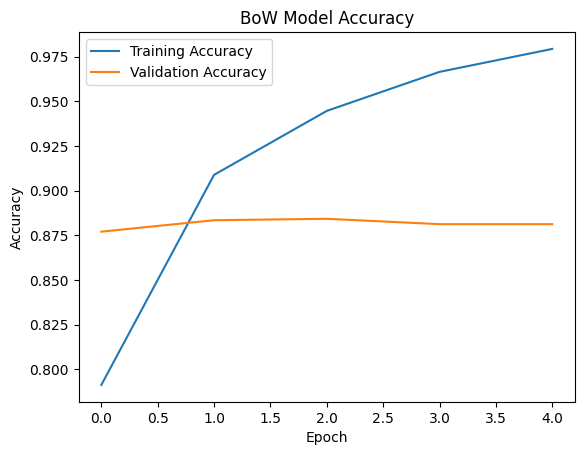

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_bow = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_bow.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_bow.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bow.summary()

history_bow = model_bow.fit(
    X_train_bow.toarray(), y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=512,
    verbose=1
)

# Plot accuracy
plt.plot(history_bow.history['accuracy'], label='Training Accuracy')
plt.plot(history_bow.history['val_accuracy'], label='Validation Accuracy')
plt.title('BoW Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# **Step 5: Evaluate the BoW Model**
This step evaluates the BoW model on test data using accuracy, confusion matrix, and a classification report (precision, recall, and F1-score).

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

BoW Model Test Accuracy: 0.86372


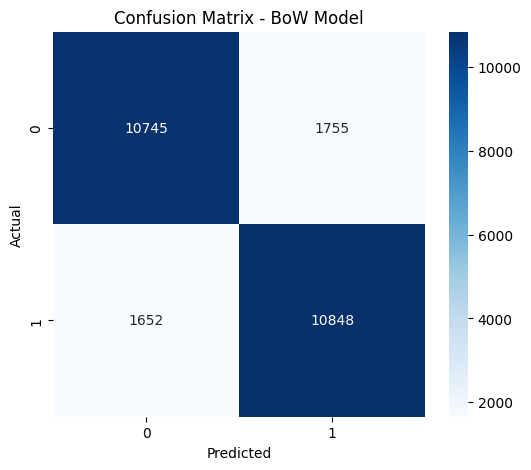


Classification Report (BoW Model):
               precision    recall  f1-score   support

           0       0.87      0.86      0.86     12500
           1       0.86      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [ ]:
pred_bow = (model_bow.predict(X_test_bow.toarray()) > 0.5).astype("int32")
bow_acc = accuracy_score(y_test, pred_bow)
print("\nBoW Model Test Accuracy:", bow_acc)

# Confusion matrix
cm_bow = confusion_matrix(y_test, pred_bow)
plt.figure(figsize=(6,5))
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - BoW Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print("\nClassification Report (BoW Model):\n", classification_report(y_test, pred_bow))

# **Step 6: Feature Extraction — TF-IDF**
Here we apply TF-IDF (Term Frequency–Inverse Document Frequency) to capture not only word occurrence but also its importance relative to other documents.

In [ ]:
# TfidfVectorizer for feature extraction
vectorizer_tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = vectorizer_tfidf.fit_transform(train_text)
X_test_tfidf = vectorizer_tfidf.transform(test_text)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF feature matrix shape (test):", X_test_tfidf.shape)

TF-IDF feature matrix shape (train): (25000, 9477)
TF-IDF feature matrix shape (test): (25000, 9477)


# **Step 7: Modeling (TF-IDF Model)**
We define and train another dense neural network, this time using TF-IDF features. The structure mirrors the BoW model to ensure fair comparison.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     1,213,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,505 (4.66 MB)

 Trainable params: 1,221,505 (4.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.6991 - loss: 0.6586 - val_accuracy: 0.8678 - val_loss: 0.3901
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8845 - loss: 0.3188 - val_accuracy: 0.8864 - val_loss: 0.2687
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9337 - loss: 0.1843 - val_accuracy: 0.8860 - val_loss: 0.2767
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9572 - loss: 0.1303 - val_accuracy: 0.8848 - val_loss: 0.3000
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9688 - loss: 0.1039 - val_accuracy: 0.8812 - val_loss: 0.3331


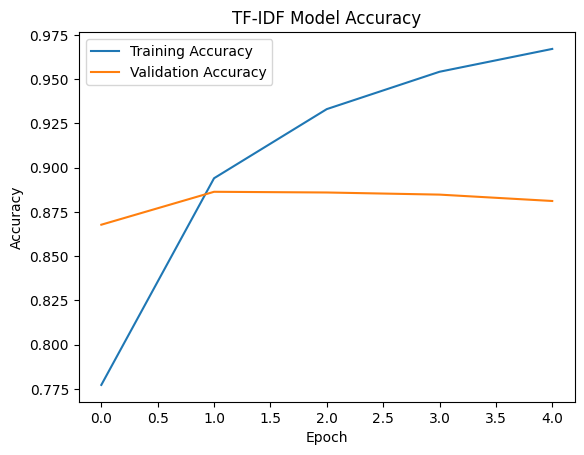

In [ ]:
model_tfidf = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_tfidf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tfidf.summary()

# Train TF-IDF model
history_tfidf = model_tfidf.fit(
    X_train_tfidf.toarray(), y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=512,
    verbose=1
)

# Plot accuracy
plt.plot(history_tfidf.history['accuracy'], label='Training Accuracy')
plt.plot(history_tfidf.history['val_accuracy'], label='Validation Accuracy')
plt.title('TF-IDF Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


* Both Bag-of-Words and TF-IDF achieved approximately 88–89 % validation accuracy on the IMDB sentiment dataset.

* BoW performed marginally better in this case, likely because word frequency itself is a strong indicator of sentiment polarity.

* TF-IDF, however, produced slightly lower validation loss, indicating more calibrated confidence in predictions.

# **Step 8: Evaluate the TF-IDF Model**
We assess the TF-IDF model’s performance using the same metrics to determine
if TF-IDF improves generalization compared with BoW.

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

TF-IDF Model Test Accuracy: 0.85552


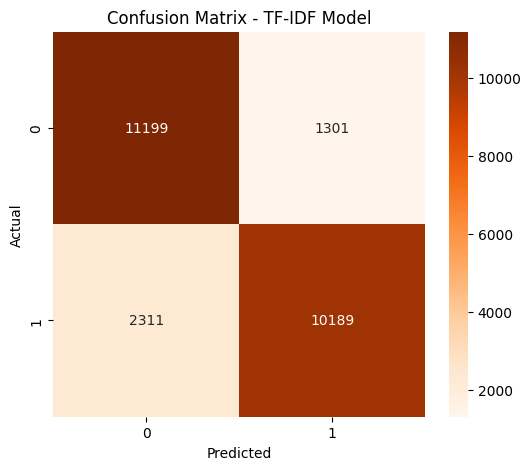


Classification Report (TF-IDF Model):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86     12500
           1       0.89      0.82      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [ ]:
pred_tfidf = (model_tfidf.predict(X_test_tfidf.toarray()) > 0.5).astype("int32")
tfidf_acc = accuracy_score(y_test, pred_tfidf)
print("\nTF-IDF Model Test Accuracy:", tfidf_acc)

# Confusion matrix
cm_tfidf = confusion_matrix(y_test, pred_tfidf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - TF-IDF Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print("\nClassification Report (TF-IDF Model):\n", classification_report(y_test, pred_tfidf))

The TF-IDF model achieved a test accuracy of 85.55%, which is slightly lower than the 86.37% obtained by the Bag-of-Words (BoW) model. Both models demonstrate nearly identical macro and weighted averages for precision, recall, and F1-score (≈0.86), indicating comparable overall performance.

These results suggest that TF-IDF did not significantly improve generalization compared to BoW, but it provided a modest shift in class sensitivity, favoring negative sentiment detection. The minor difference in performance (≈0.8%) falls within normal variation and confirms that both vectorization techniques yield strong, reliable baselines for sentiment analysis tasks on the IMDB dataset.

# **Step 9: Comparison Summary**
We summarize both models’ accuracies and plot them side by side to visualize which feature extraction method produced better results.


BoW Model Accuracy:   0.8637
TF-IDF Model Accuracy: 0.8555


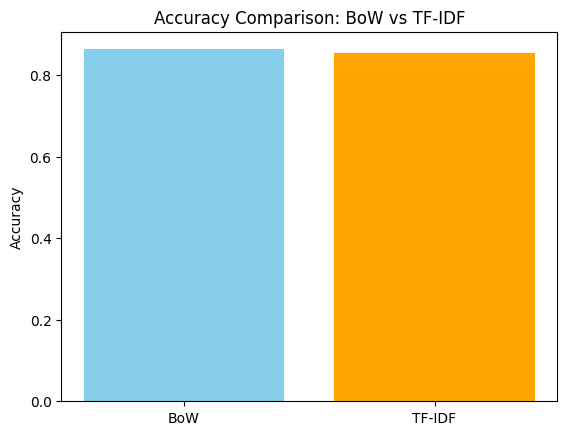

In [ ]:
print(f"\nBoW Model Accuracy:   {bow_acc:.4f}")
print(f"TF-IDF Model Accuracy: {tfidf_acc:.4f}")

# Bar chart for comparison
plt.bar(['BoW', 'TF-IDF'], [bow_acc, tfidf_acc], color=['skyblue', 'orange'])
plt.title('Accuracy Comparison: BoW vs TF-IDF')
plt.ylabel('Accuracy')
plt.show()


When visualized side by side, the accuracy scores reveal only a marginal gap between the two models. The **BoW model’s slight advantage** indicates that representing text through raw word counts was marginally more effective for this dataset. However, the **TF-IDF model’s performance remains competitive**, showing that both vectorization techniques are capable of producing robust sentiment classifiers. The overall similarity in accuracy emphasizes that **model performance depends more on data representation quality and neural network design** than on minor differences between these two feature extraction methods.

# **Sample Analysis**

In [ ]:
import pickle
from tensorflow.keras.models import load_model
import numpy as np

model = load_model('bow_sentiment_model.h5')

with open('bow_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# input text/s here
texts = [
    "worst movie of all time!",
    "I really enjoyed this film, it was amazing!"
]

text_vec = vectorizer.transform(texts).toarray()

preds = model.predict(text_vec)

for text, pred in zip(texts, preds):
    sentiment = "Positive" if pred[0] > 0.5 else "Negative"
    print(f"Text: {text}\nPredicted sentiment: {sentiment}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Text: worst movie of all time!
Predicted sentiment: Negative

Text: I really enjoyed this film, it was amazing!
Predicted sentiment: Positive

